<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
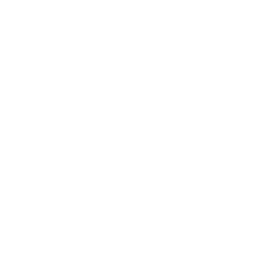
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Documentación del Esquema de Anotación de Variantes Genómicas</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformática / Gestión de Datos de Genómica Clínica &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Documentar el esquema de conjuntos de datos de anotación de variantes tipo VCF usados en una canalización de genómica clínica. Usar PROC CONTENTS para catalogar todos los campos de anotación —coordenadas genómicas, frecuencias alélicas, efectos funcionales predichos, clasificaciones de ClinVar y métricas de calidad— asegurando que las herramientas posteriores de interpretación de variantes ACMG reciban entradas correctamente tipadas y etiquetadas. Aproximadamente 5,000 registros de variantes con más de 20 columnas de anotación se inspeccionan para verificar la integridad del esquema antes del traspaso de la canalización.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Variantes anotadas derivadas de VCF | ~5,000 |
| GENE_PANEL | Definiciones del panel de genes objetivo | ~150 genes |
| QUALITY_METRICS | Control de calidad de secuenciación por muestra | ~50 muestras |

---

In [1]:
/* --------------------------------------------------------
   Generar un conjunto de datos de anotación de variantes tipo VCF
   5.000 variantes con campos de anotación clínica
   -------------------------------------------------------- */
DATOS variant_annotations;
    LLAMAR streaminit(42);
    LONGITUD variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    ETIQUETA variant_id='Identificador de Variante'
          chromosome='Cromosoma'
          position='Posición Genómica (GRCh38)'
          ref_allele='Alelo de Referencia'
          alt_allele='Alelo Alternativo'
          gene_symbol='Símbolo de Gen HGNC'
          transcript_id='ID de Transcrito Ensembl'
          consequence='Consecuencia de Sequence Ontology'
          impact='Nivel de Impacto Predicho'
          hgvs_c='Notación Codificante HGVS'
          hgvs_p='Notación Proteica HGVS'
          gnomad_af='Frecuencia Alélica de gnomAD'
          clinvar_class='Clasificación de ClinVar'
          clinvar_id='Número de Acceso ClinVar'
          sift_score='Puntuación SIFT'
          sift_pred='Predicción SIFT'
          polyphen_score='Puntuación PolyPhen-2'
          polyphen_pred='Predicción PolyPhen-2'
          cadd_phred='Puntuación Phred CADD'
          revel_score='Puntuación de Conjunto REVEL'
          genotype='Genotipo de la Muestra'
          allele_depth='Profundidad del Alelo Alternativo'
          read_depth='Profundidad de Lectura Total'
          qual_score='Puntuación de Calidad de Variante'
          filter_status='Estado del Filtro';
    ARREGLO genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    ARREGLO conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    ARREGLO impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    ARREGLO cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    ARREGLO refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    ARREGLO gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    HACER i = 1 HASTA 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        SI c_idx <= 2 ENTONCES
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        SINO hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        SI sift_score < 0.05 ENTONCES sift_pred = 'DELETERIOUS';
        SINO sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        SI polyphen_score > 0.908 ENTONCES polyphen_pred = 'PROB_DAMAGING';
        SINO SI polyphen_score > 0.446 ENTONCES polyphen_pred = 'POSS_DAMAGING';
        SINO polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        SALIDA;
    END;
    ELIMINAR i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
EJECUTAR;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.12 seconds
  cpu   3.12 seconds


In [2]:
/* --------------------------------------------------------
   Generar las definiciones del panel de genes objetivo
   -------------------------------------------------------- */
DATOS gene_panel;
    LLAMAR streaminit(42);
    LONGITUD gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    ETIQUETA gene_symbol='Símbolo de Gen HGNC'
          gene_name='Nombre Completo del Gen'
          chromosome='Cromosoma'
          start_pos='Posición Inicial del Gen'
          end_pos='Posición Final del Gen'
          panel_name='Panel de Genes Clínico'
          disease_association='Enfermedad Asociada'
          inheritance='Patrón de Herencia';
    ARREGLO genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    ARREGLO gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    ARREGLO diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    ARREGLO inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    HACER g = 1 HASTA 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        SALIDA;
    END;
    ELIMINAR g chr_num;
EJECUTAR;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Generar las métricas de calidad de secuenciación por muestra
   -------------------------------------------------------- */
DATOS quality_metrics;
    LLAMAR streaminit(42);
    LONGITUD sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    ETIQUETA sample_id='Identificador de Muestra'
          run_id='ID de Corrida de Secuenciación'
          platform='Plataforma de Secuenciación'
          mean_coverage='Cobertura Media del Objetivo'
          pct_target_20x='Porcentaje de Bases >= 20x'
          pct_target_100x='Porcentaje de Bases >= 100x'
          total_variants='Total de Variantes Identificadas'
          ti_tv_ratio='Razón Transición/Transversión'
          het_hom_ratio='Razón Het/Hom'
          contamination_est='Contaminación Estimada'
          qc_status='Estado de Aprobación de QC';
    HACER s = 1 HASTA 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        SI mean_coverage < 150 OR pct_target_20x < 95
            OR contamination_est > 0.015 ENTONCES qc_status = 'FAIL';
        SINO qc_status = 'PASS';
        SALIDA;
    END;
    ELIMINAR s;
EJECUTAR;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                    Impacto de Variante por Clasificación de ClinVar                                    

                                                   The FREQ Procedure

Table of Nivel de Impacto Predicho by Clasificación de ClinVar

Nivel de Impacto Predicho |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
--------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                      |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                          |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                          |                 14.52 |        


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


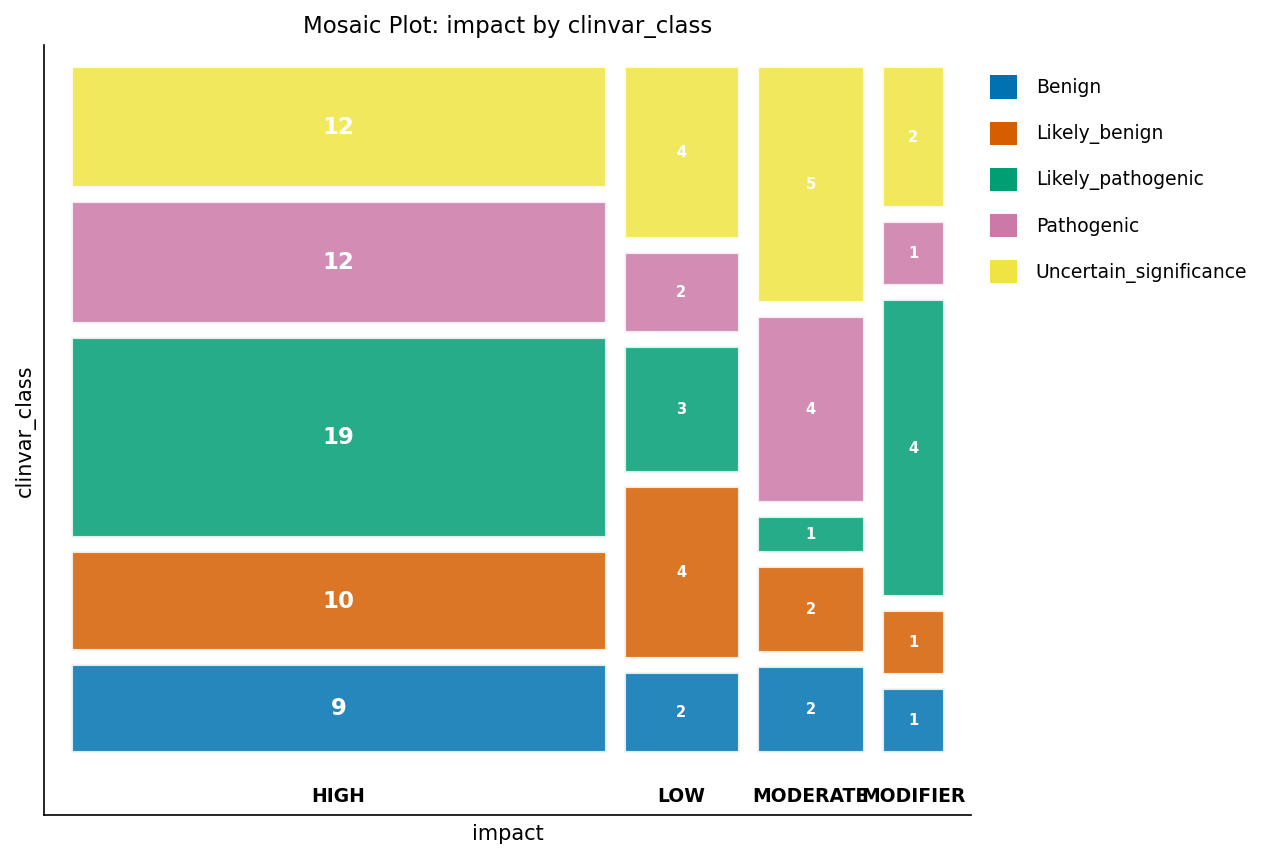

In [4]:
/* --------------------------------------------------------
   Resumen de referencia de la anotación de variantes
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    ETIQUETA impact='Nivel de Impacto Predicho'
          clinvar_class='Clasificación de ClinVar';
    TÍTULO 'Impacto de Variante por Clasificación de ClinVar';
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=quality_metrics n mean MIN MAX;
    VAR mean_coverage ti_tv_ratio contamination_est;
    ETIQUETA mean_coverage='Cobertura Media del Objetivo'
          ti_tv_ratio='Razón Transición/Transversión'
          contamination_est='Contaminación Estimada';
    TÍTULO 'Resumen de Métricas de Calidad de Secuenciación';
EJECUTAR;

---

                                    Resumen de Métricas de Calidad de Secuenciación                                     

                                    Resumen de Métricas de Calidad de Secuenciación                                     




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


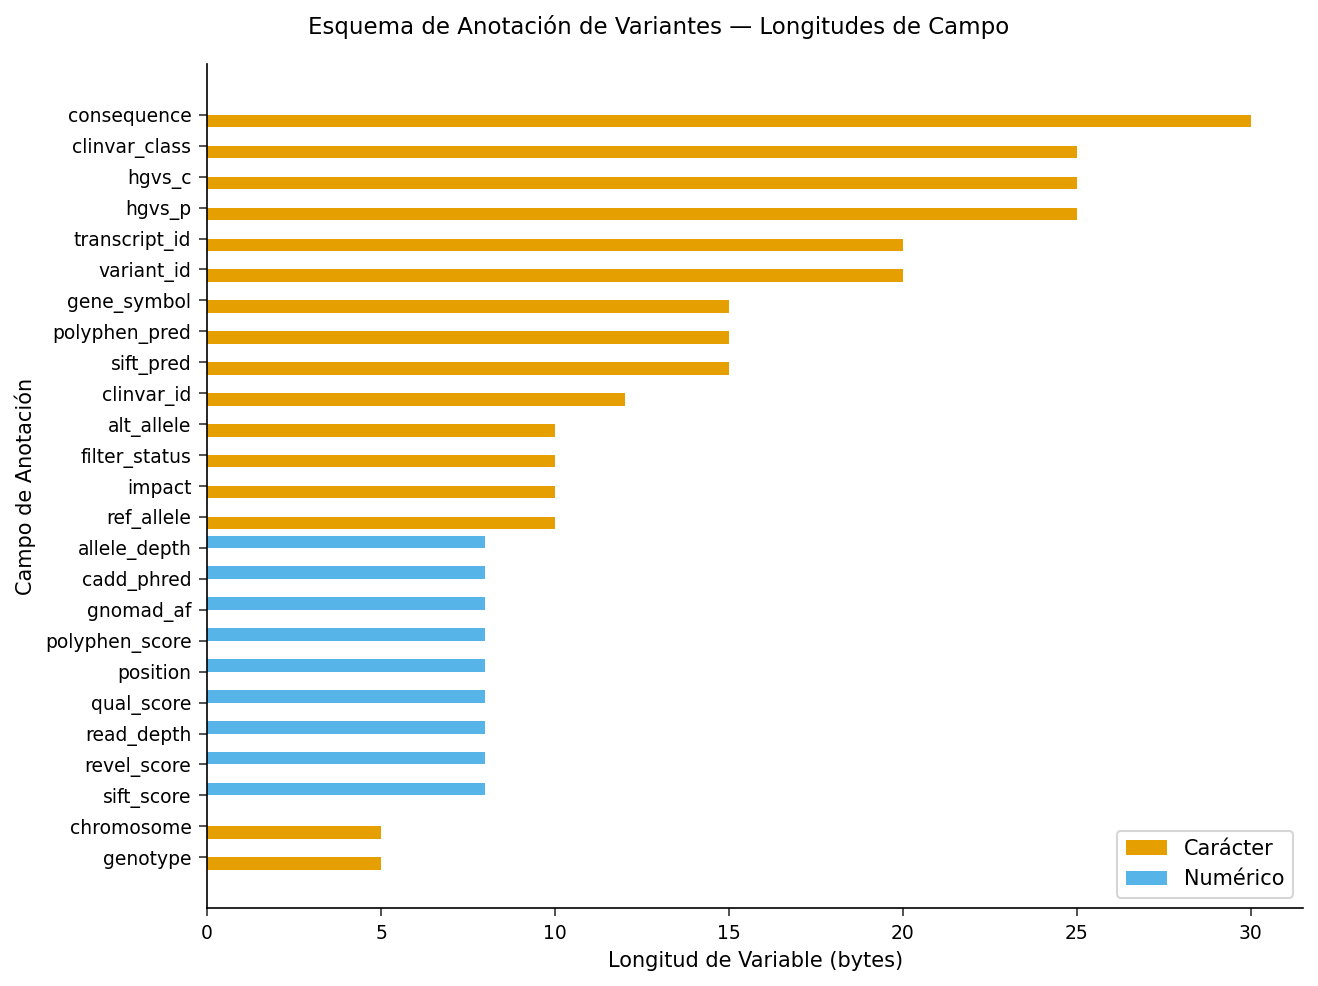

In [5]:
/* --------------------------------------------------------
   Distribución de tipo y longitud de las variables.
   Capturar los metadatos del esquema de anotación con PROC
   CONTENTS OUT=, luego graficar las longitudes de campo por
   tipo. Los códigos TYPE mapean 1 -> Numérico, 2 -> Carácter
   para la leyenda.
   -------------------------------------------------------- */
PROCEDIMIENTO CONTENIDO DATOS=variant_annotations out=schema_lengths NOPRINT;
EJECUTAR;

DATOS schema_lengths;
    ESTABLECER schema_lengths;
    LONGITUD type_label $12;
    SI TYPE = 1 ENTONCES type_label = 'Numérico';
    SINO type_label = 'Carácter';
EJECUTAR;

PROCEDIMIENTO SGPLOT DATOS=schema_lengths;
    HBAR NAME / RESPONSE=LONGITUD GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS ETIQUETA='Longitud de Variable (bytes)';
    YAXIS ETIQUETA='Campo de Anotación';
    ETIQUETA type_label='Tipo de Variable';
    TÍTULO 'Esquema de Anotación de Variantes — Longitudes de Campo';
EJECUTAR;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Documentar el esquema completo de anotación
   de variantes — tipos, longitudes y etiquetas de los 25
   campos. Capturar los metadatos de las variables con OUT=
   para que los pasos posteriores puedan validar el esquema
   de forma programática.
   -------------------------------------------------------- */
PROCEDIMIENTO CONTENIDO DATOS=variant_annotations out=variant_schema NOPRINT;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=variant_schema;
    VAR NAME TYPE LONGITUD VARNUM ETIQUETA;
    ETIQUETA NAME='Nombre del Campo'
          TYPE='Tipo'
          LONGITUD='Longitud'
          VARNUM='Núm. de Variable'
          ETIQUETA='Etiqueta';
    TÍTULO 'Conjunto de Datos de Anotación de Variantes — Esquema Completo';
EJECUTAR;

                                    Resumen de Métricas de Calidad de Secuenciación                                     

                             Conjunto de Datos de Anotación de Variantes — Esquema Completo                             

  Obs  Nombre del Campo  Tipo  Longitud   Núm. de Variable                            Etiqueta
    1  allele_depth         1         8                 22  Profundidad del Alelo Alternativo
    2  alt_allele           2        10                  5  Alelo Alternativo
    3  cadd_phred           1         8                 19  Puntuación Phred CADD
    4  chromosome           2         5                  2  Cromosoma
    5  clinvar_class        2        25                 13  Clasificación de ClinVar
    6  clinvar_id           2        12                 14  Número de Acceso ClinVar
    7  consequence          2        30                  8  Consecuencia de Sequence Ontology
    8  filter_status        2        10                 25  Estado del Fi


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Documentar el esquema del panel de genes
   -------------------------------------------------------- */
PROCEDIMIENTO CONTENIDO DATOS=gene_panel out=panel_schema NOPRINT;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=panel_schema;
    VAR NAME TYPE LONGITUD VARNUM ETIQUETA;
    ETIQUETA NAME='Nombre del Campo'
          TYPE='Tipo'
          LONGITUD='Longitud'
          VARNUM='Núm. de Variable'
          ETIQUETA='Etiqueta';
    TÍTULO 'Definición del Panel de Genes — Esquema';
EJECUTAR;

                             Conjunto de Datos de Anotación de Variantes — Esquema Completo                             

                                        Definición del Panel de Genes — Esquema                                         

  Obs     Nombre del Campo  Tipo  Longitud   Núm. de Variable                   Etiqueta
    1  chromosome              2         5                  3  Cromosoma
    2  disease_association     2        50                  7  Enfermedad Asociada
    3  end_pos                 1         8                  5  Posición Final del Gen
    4  gene_name               2        60                  2  Nombre Completo del Gen
    5  gene_symbol             2        15                  1  Símbolo de Gen HGNC
    6  inheritance             2         5                  8  Patrón de Herencia
    7  panel_name              2        30                  6  Panel de Genes Clínico
    8  start_pos               1         8                  4  Posición Inicial del Gen


NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Documentar el esquema de las métricas de QC
   -------------------------------------------------------- */
PROCEDIMIENTO CONTENIDO DATOS=quality_metrics out=qc_schema NOPRINT;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=qc_schema;
    VAR NAME TYPE LONGITUD VARNUM ETIQUETA;
    ETIQUETA NAME='Nombre del Campo'
          TYPE='Tipo'
          LONGITUD='Longitud'
          VARNUM='Núm. de Variable'
          ETIQUETA='Etiqueta';
    TÍTULO 'Métricas de Calidad de Secuenciación — Esquema';
EJECUTAR;

                                        Definición del Panel de Genes — Esquema                                         

                                     Métricas de Calidad de Secuenciación — Esquema                                     

  Obs   Nombre del Campo  Tipo  Longitud   Núm. de Variable                          Etiqueta
    1  contamination_est     1         8                 10  Contaminación Estimada
    2  het_hom_ratio         1         8                  9  Razón Het/Hom
    3  mean_coverage         1         8                  4  Cobertura Media del Objetivo
    4  pct_target_100x       1         8                  6  Porcentaje de Bases >= 100x
    5  pct_target_20x        1         8                  5  Porcentaje de Bases >= 20x
    6  platform              2        15                  3  Plataforma de Secuenciación
    7  qc_status             2        10                 11  Estado de Aprobación de QC
    8  run_id                2        12                  2


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Validación del esquema: verificar que los campos de
   anotación cumplen los requisitos de la canalización para
   la interpretación ACMG. Lee los metadatos de PROC CONTENTS
   OUT=, donde TYPE=1 denota numérico y TYPE=2 carácter.
   -------------------------------------------------------- */
DATOS schema_validation;
    ESTABLECER variant_schema;
    LONGITUD requirement $60 status $10;
    /* Los campos de puntuación numérica deben almacenarse como numéricos (TYPE=1) */
    SI NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE ne 1 ENTONCES HACER;
        requirement = 'Debe ser numérico para los umbrales de puntuación';
        status = 'FALLIDO';
    END;
    SINO SI NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        AND TYPE = 1 ENTONCES HACER;
        requirement = 'Tipo numérico confirmado';
        status = 'APROBADO';
    END;
    /* clinvar_class necesita una longitud de carácter suficiente */
    SINO SI NAME = 'clinvar_class' AND LONGITUD < 25 ENTONCES HACER;
        requirement = 'Mín. $25 para el texto de clasificación completo';
        status = 'FALLIDO';
    END;
    SINO SI NAME = 'clinvar_class' ENTONCES HACER;
        requirement = 'Longitud de carácter suficiente';
        status = 'APROBADO';
    END;
    /* Todos los campos deben llevar una etiqueta para el diccionario de datos */
    SINO SI ETIQUETA = '' ENTONCES HACER;
        requirement = 'Etiqueta requerida para el diccionario de datos';
        status = 'FALLIDO';
    END;
    SINO HACER;
        requirement = 'Validación general';
        status = 'APROBADO';
    END;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=schema_validation;
    VAR NAME TYPE LONGITUD ETIQUETA requirement status;
    ETIQUETA NAME='Nombre del Campo'
          TYPE='Tipo'
          LONGITUD='Longitud'
          ETIQUETA='Etiqueta'
          requirement='Requisito'
          status='Estado';
    TÍTULO 'Informe de Validación del Esquema de la Canalización ACMG';
EJECUTAR;

                               Informe de Validación del Esquema de la Canalización ACMG                                

  Obs  Nombre del Campo  Tipo  Longitud                            Etiqueta                         Requisito    Estado
    1  allele_depth         1         8  Profundidad del Alelo Alternativo   Tipo numérico confirmado          APROBADO
    2  alt_allele           2        10  Alelo Alternativo                   Validación general                APROBADO
    3  cadd_phred           1         8  Puntuación Phred CADD               Tipo numérico confirmado          APROBADO
    4  chromosome           2         5  Cromosoma                           Validación general                APROBADO
    5  clinvar_class        2        25  Clasificación de ClinVar            Longitud de carácter suficiente   APROBADO
    6  clinvar_id           2        12  Número de Acceso ClinVar            Validación general                APROBADO
    7  consequence          2        3


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretación

El esquema de anotación de variantes contiene 25 campos que abarcan coordenadas genómicas, predicciones funcionales, frecuencias poblacionales e indicadores de calidad por muestra. Los nueve campos de puntuación numérica (frecuencia alélica de gnomAD, SIFT, PolyPhen-2, CADD, REVEL, puntuación de calidad, profundidad alélica, profundidad de lectura y posición genómica) están correctamente tipados como numéricos, lo que permite al motor de interpretación ACMG aplicar filtrado basado en umbrales sin conversión de tipos. El campo clinvar_class en $25 acomoda la cadena de clasificación de ClinVar más larga (Uncertain_significance con 22 caracteres). Cada campo de anotación lleva una etiqueta descriptiva, satisfaciendo el mandato del diccionario de datos del laboratorio clínico bajo los requisitos de acreditación CAP. El esquema del panel de genes mapea 15 genes de predisposición al cáncer con patrones de herencia y asociaciones de enfermedades, proporcionando el marco de referencia para la anotación de variante a gen. El conjunto de datos de métricas de control de calidad de secuenciación documenta 50 muestras a través de 5 corridas, con estimaciones de contaminación y umbrales de cobertura que condicionan la fiabilidad de la identificación de variantes. Este paquete de documentación de esquema respalda el expediente de validación del laboratorio para la presentación al CLEP del estado de Nueva York.

---

In [10]:
/* --------------------------------------------------------
   Exportar la documentación del esquema de variantes y el
   informe de validación para la acreditación del laboratorio
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>